<a href="https://colab.research.google.com/github/Mia-NK/Intro-to-Data-Science-DTSC-3010---Final-Project-Home-Loan-Approval-Prediction/blob/main/3010_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #dataframe manip
import numpy as np #dataframe manip
import matplotlib.pyplot as plt #visualization
import seaborn as sns #visualization
from sklearn.impute import SimpleImputer #data cleaning
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder #data standardization
from sklearn.feature_selection import mutual_info_classif #visualization

In [ ]:
training_original = pd.read_csv('Loan approval TRAINING SET - OG.csv')
test_original = pd.read_csv('Loan approval TEST SET - OG.csv')

display(training_original.head(), test_original.head())
training_original.dtypes, test_original.dtypes

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


(Loan_ID               object
 Gender                object
 Married               object
 Dependents            object
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome    float64
 LoanAmount           float64
 Loan_Amount_Term     float64
 Credit_History       float64
 Property_Area         object
 Loan_Status           object
 dtype: object,
 Loan_ID               object
 Gender                object
 Married               object
 Dependents            object
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome      int64
 LoanAmount           float64
 Loan_Amount_Term     float64
 Credit_History       float64
 Property_Area         object
 dtype: object)

**INITIAL IMPRESSION**


1.   NAN values need to be addressed
2.   Categorical values [Y/N] should be dummy encoded
3.   Dependents needs to be configured into numerical values
4.   All data need to be scaled for proper comparison



**STEPS**



---


1.   Handle messy data [address NaN, convert data types, etc]
2.   POST-CLEANING EDA [look at initial patterns and distributions]
3.   Visualize / outlier analysis [minmax = more sentiive to outliers; z-score = more robust against outliers]
4.   Normalize data based on anomaly detection results
5.  POST-STANDARDIZATION EDA
6.  Modeling



# Inspection [pre-cleaning]

In [ ]:
display(training_original.describe(include='all'))
#TRAINING summary stats

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [ ]:
display(test_original.describe(include='all'))
#TEST summary stats

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,367,356,367,357,367,344,367.000000,367.000000,362.000000,361.000000,338.000000,367
unique,367,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3
top,LP002989,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Urban
freq,1,286,233,200,283,307,NaN,NaN,NaN,NaN,NaN,140
mean,NaN,NaN,NaN,NaN,NaN,NaN,4805.599455,1569.577657,136.132597,342.537396,0.825444,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,4910.685399,2334.232099,61.366652,65.156643,0.380150,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,28.000000,6.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2864.000000,0.000000,100.250000,360.000000,1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3786.000000,1025.000000,125.000000,360.000000,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5060.000000,2430.500000,158.000000,360.000000,1.000000,NaN


In [ ]:
print("Shape of the original training data:", training_original.shape)
print("NaN values by column [training set]:\n", training_original.isnull().sum())
print("Total no. of training rows with NaN:", training_original.isnull().any(axis=1).sum())

print("\nShape of the original test data:", test_original.shape)
print("NaN values by column [testing set]:\n", test_original.isnull().sum())
print("Total no. of testing rows with NaN:", test_original.isnull().any(axis=1).sum())

Shape of the original training data: (614, 13)
NaN values by column [training set]:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
Total no. of training rows with NaN: 134

Shape of the original test data: (367, 12)
NaN values by column [testing set]:
 Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64
Total no. of testing rows with NaN: 78


In [ ]:
#Looking for duplicates in the data

print(training_original.duplicated(subset=['Loan_ID']).sum())
print(test_original.duplicated(subset=['Loan_ID']).sum())

0
0


# Data cleaning

In [ ]:
training_clean = training_original.copy()
test_clean = test_original.copy()

In [ ]:
freq_imp = SimpleImputer(strategy='most_frequent')
#imputing the categorical data + loan term data with the most frequently occurring values

training_clean[['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term',
              'Credit_History']] = freq_imp.fit_transform(training_clean[['Gender',
              'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']])
print(training_clean.isnull().sum(), training_clean.shape)

test_clean[['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term',
              'Credit_History']] = freq_imp.fit_transform(test_clean[['Gender',
              'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']])
print(test_clean.isnull().sum(), test_clean.shape)

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64 (614, 13)
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           5
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64 (367, 12)


In [ ]:
mean_imp = SimpleImputer(strategy='mean')
#imputing continuous data with the average value

training_clean[['LoanAmount']] = mean_imp.fit_transform(training_clean[['LoanAmount']])
print(training_clean.isnull().sum(), training_clean.shape)

test_clean[['LoanAmount']] = mean_imp.fit_transform(test_clean[['LoanAmount']])
print(test_clean.isnull().sum(), test_clean.shape)

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64 (614, 13)
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64 (367, 12)


In [ ]:
training_clean.head(10), training_clean.dtypes, test_clean.head(10), test_clean.dtypes

(    Loan_ID Gender Married Dependents     Education Self_Employed  \
 0  LP001002   Male      No          0      Graduate            No   
 1  LP001003   Male     Yes          1      Graduate            No   
 2  LP001005   Male     Yes          0      Graduate           Yes   
 3  LP001006   Male     Yes          0  Not Graduate            No   
 4  LP001008   Male      No          0      Graduate            No   
 5  LP001011   Male     Yes          2      Graduate           Yes   
 6  LP001013   Male     Yes          0  Not Graduate            No   
 7  LP001014   Male     Yes         3+      Graduate            No   
 8  LP001018   Male     Yes          2      Graduate            No   
 9  LP001020   Male     Yes          1      Graduate            No   
 
    ApplicantIncome  CoapplicantIncome  LoanAmount Loan_Amount_Term  \
 0             5849                0.0  146.412162            360.0   
 1             4583             1508.0  128.000000            360.0   
 2             

In [ ]:
display(training_clean['Dependents'])
display(test_clean['Dependents'])
#Original dataset compiled values >= 3 as '3+' so we need
# to handle the unqiue string character

,Dependents
0,0
1,1
2,0
3,0
4,0
...,...
609,0
610,3+
611,1
612,2


,Dependents
0,0
1,1
2,2
3,2
4,0
...,...
362,3+
363,0
364,0
365,0


In [ ]:
training_clean['Dependents'] = training_clean['Dependents'].str.replace('+', '')
test_clean['Dependents'] = test_clean['Dependents'].str.replace('+', '')

training_clean['Dependents'] = pd.to_numeric(training_clean['Dependents'])
test_clean['Dependents'] = pd.to_numeric(test_clean['Dependents'])

training_clean.dtypes, test_clean.dtypes

(Loan_ID               object
 Gender                object
 Married               object
 Dependents             int64
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome    float64
 LoanAmount           float64
 Loan_Amount_Term      object
 Credit_History        object
 Property_Area         object
 Loan_Status           object
 dtype: object,
 Loan_ID               object
 Gender                object
 Married               object
 Dependents             int64
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome      int64
 LoanAmount           float64
 Loan_Amount_Term      object
 Credit_History        object
 Property_Area         object
 dtype: object)

In [ ]:
training_clean['Loan_Amount_Term'] = pd.to_numeric(training_clean['Loan_Amount_Term'])
test_clean['Loan_Amount_Term'] = pd.to_numeric(test_clean['Loan_Amount_Term'])

training_clean.dtypes, test_clean.dtypes

(Loan_ID               object
 Gender                object
 Married               object
 Dependents             int64
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome    float64
 LoanAmount           float64
 Loan_Amount_Term     float64
 Credit_History        object
 Property_Area         object
 Loan_Status           object
 dtype: object,
 Loan_ID               object
 Gender                object
 Married               object
 Dependents             int64
 Education             object
 Self_Employed         object
 ApplicantIncome        int64
 CoapplicantIncome      int64
 LoanAmount           float64
 Loan_Amount_Term     float64
 Credit_History        object
 Property_Area         object
 dtype: object)

**Encoding guide**
Bool 0 = false, true = 1


*   **Gender** - 0: FEMALE 1: MALE
*   **Married** - 0: NO, 1: YES
*   **Education** - 0: NOT GRADUATE, 1: GRADUATE
*   **Self_Employed** - 0: NO, 1: YES
*   **Property_Area** - One-hot encoding
*   **Loan_Status** - 0: NO, 1: YES



In [ ]:
training_clean.head(3), test_clean.head(3)

(      Loan_ID  Gender Married  Dependents     Education Self_Employed  \
 0    LP001002    Male      No           0      Graduate            No   
 1    LP001003    Male     Yes           1      Graduate            No   
 2    LP001005    Male     Yes           0      Graduate           Yes   
 3    LP001006    Male     Yes           0  Not Graduate            No   
 4    LP001008    Male      No           0      Graduate            No   
 ..        ...     ...     ...         ...           ...           ...   
 609  LP002978  Female      No           0      Graduate            No   
 610  LP002979    Male     Yes           3      Graduate            No   
 611  LP002983    Male     Yes           1      Graduate            No   
 612  LP002984    Male     Yes           2      Graduate            No   
 613  LP002990  Female      No           0      Graduate           Yes   
 
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
 0               5849               

In [ ]:
training_clean['Gender'] = training_original['Gender'].map({'Female': 0, 'Male': 1})
test_clean['Gender'] = test_clean['Gender'].map({'Female': 0, 'Male': 1})

training_clean['Married'] = training_clean['Married'].map({'No': 0, 'Yes': 1})
test_clean['Married'] = test_clean['Married'].map({'No': 0, 'Yes': 1})

training_clean['Education'] = training_clean['Education'].map({'Not Graduate': 0, 'Graduate': 1})
test_clean['Education'] = test_clean['Education'].map({'Not Graduate': 0, 'Graduate': 1})

training_clean['Self_Employed'] = training_clean['Self_Employed'].map({'No': 0, 'Yes': 1})
test_clean['Self_Employed'] = test_clean['Self_Employed'].map({'No': 0, 'Yes': 1})

training_clean['Loan_Status'] = training_clean['Loan_Status'].map({'N': 0, 'Y': 1})

training_clean, test_clean

(      Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
 0    LP001002     1.0        0           0          1              0   
 1    LP001003     1.0        1           1          1              0   
 2    LP001005     1.0        1           0          1              1   
 3    LP001006     1.0        1           0          0              0   
 4    LP001008     1.0        0           0          1              0   
 ..        ...     ...      ...         ...        ...            ...   
 609  LP002978     0.0        0           0          1              0   
 610  LP002979     1.0        1           3          1              0   
 611  LP002983     1.0        1           1          1              0   
 612  LP002984     1.0        1           2          1              0   
 613  LP002990     0.0        0           0          1              1   
 
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
 0               5849                0.0  146.41

In [ ]:
#Need to use one-hot encoding for property area since all three categories are important
ohe = OneHotEncoder(sparse_output=False, dtype=np.int64, handle_unknown='ignore')

encoded_property_area_training = training_clean[['Property_Area']]
encoded_property_area_test = test_clean[['Property_Area']]

encoded_property_area_training = ohe.fit_transform(encoded_property_area_training)
encoded_property_area_test = ohe.transform(encoded_property_area_test)

In [ ]:
columns = ohe.get_feature_names_out()

df_encoded_property_area_training = pd.DataFrame(encoded_property_area_training,
                                                 columns=columns, index=training_clean.index)
df_encoded_property_area_test = pd.DataFrame(encoded_property_area_test,
                                             columns=columns, index=test_clean.index)

#Displaying for veryifying encoding
print("Original data:\nTraining:\n", training_clean['Property_Area'].head(),
      "\nTesting:\n", test_clean['Property_Area'].head())
print("\nOne Hot Encoded:\nTraining\n", df_encoded_property_area_training.head(),
      "\nTesting:\n", df_encoded_property_area_test.head())

Original data:
Training:
 0    Urban
1    Rural
2    Urban
3    Urban
4    Urban
Name: Property_Area, dtype: object 
Testing:
 0    Urban
1    Urban
2    Urban
3    Urban
4    Urban
Name: Property_Area, dtype: object

One Hot Encoded:
Training
    Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban
0                    0                        0                    1
1                    1                        0                    0
2                    0                        0                    1
3                    0                        0                    1
4                    0                        0                    1 
Testing:
    Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban
0                    0                        0                    1
1                    0                        0                    1
2                    0                        0                    1
3                    0                        0       

In [ ]:
training_clean = pd.concat([training_clean, df_encoded_property_area_training], axis=1)
test_clean = pd.concat([test_clean, df_encoded_property_area_test], axis=1)

training_clean.drop(['Property_Area'], axis=1, inplace=True)
test_clean.drop(['Property_Area'], axis=1, inplace=True)

In [ ]:
#check datasets to make sure concatenation went smoothly
training_clean

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1.0,0,0,1,0,5849,0.0,146.412162,360.0,1.0,1,0,0,1
1,LP001003,1.0,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,1,0,0
2,LP001005,1.0,1,0,1,1,3000,0.0,66.000000,360.0,1.0,1,0,0,1
3,LP001006,1.0,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,1,0,0,1
4,LP001008,1.0,0,0,1,0,6000,0.0,141.000000,360.0,1.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0.0,0,0,1,0,2900,0.0,71.000000,360.0,1.0,1,1,0,0
610,LP002979,1.0,1,3,1,0,4106,0.0,40.000000,180.0,1.0,1,1,0,0
611,LP002983,1.0,1,1,1,0,8072,240.0,253.000000,360.0,1.0,1,0,0,1
612,LP002984,1.0,1,2,1,0,7583,0.0,187.000000,360.0,1.0,1,0,0,1


In [ ]:
test_clean

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,0,0,1
1,LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,0,0,1
2,LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,0,0,1
3,LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,0,0,1
4,LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,1,1,3,0,1,4009,1777,113.0,360.0,1.0,0,0,1
363,LP002975,1,1,0,1,0,4158,709,115.0,360.0,1.0,0,0,1
364,LP002980,1,0,0,1,0,3250,1993,126.0,360.0,1.0,0,1,0
365,LP002986,1,1,0,1,0,5000,2393,158.0,360.0,1.0,1,0,0


In [ ]:
training_clean.shape, test_clean.shape

((614, 15), (367, 14))

# Visualizing cleaned [non-standardized] data

In [ ]:
display(training_clean.describe(include='all'))

In [ ]:
display(test_clean.describe(include='all'))

**EDA - VISUAL METHODS AND WHAT THEY'RE REPRESENTING**


*   **

*   **Violin Plot** - Distribution of both approved and non-approved values based on their categorical status
*   **Correlation Matrix** - Visualization for Pearson's R (strength of relationship [-1 to 1] between variables)
*   **Pivot Analysis** - Detecting the significant independent variables based on their spread
*   **Mutual Information** - Ordered feature importance



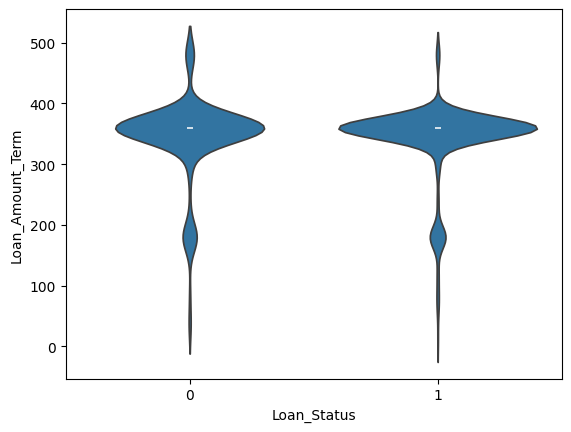

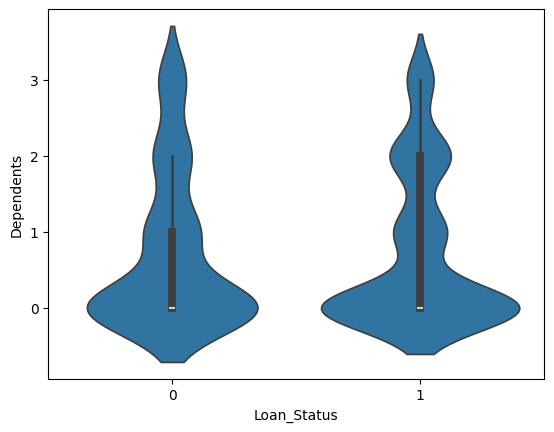

In [ ]:
sns.violinplot(x='Loan_Status', y='Loan_Amount_Term', data=training_clean)
plt.show()
sns.violinplot(x='Loan_Status', y='Dependents', data=training_clean)
plt.show()

In [ ]:
#CORRELATION

pearson_r = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                            'Loan_Amount_Term', 'Credit_History', 'Loan_Status']].corr()
pearson_r.loc[['Loan_Status']].round(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
Loan_Status,-0.0,-0.06,-0.04,-0.02,0.54,1.0


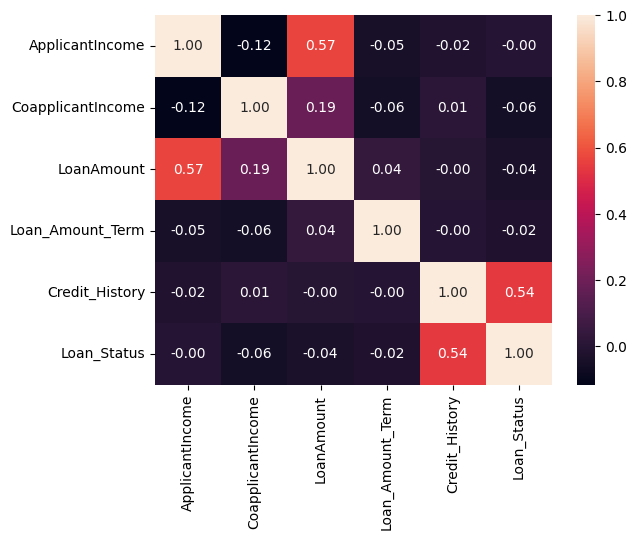

In [ ]:
#CONT... CORRELATION HEATMAP

sns.heatmap(pearson_r, annot=True, fmt=".2f")
plt.show()

In [ ]:
#PIVOT ANALYSIS
loop_cols = [col for col in training_clean.columns if col not in ['Loan_ID', 'Loan_Status']]
sig_feat = []

for col in loop_cols:
  if training_clean[col].nunique() > 10:
    bins = pd.qcut(training_clean[col], q=4, duplicates='drop')
  else:
    bins = training_clean[col]

  pivot = training_clean.pivot_table(index=bins, values='Loan_Status', aggfunc='mean', observed='False')
  spread = pivot['Loan_Status'].max() - pivot['Loan_Status'].min()

  if spread > 0.1:
    sig_feat.append(col)
    print(f"{col} spread: {spread:.2f}")
    print(pivot.round(2))

print("\nSignificant Features:", sig_feat)

Dependents spread: 0.11
            Loan_Status
Dependents             
0                  0.69
1                  0.65
2                  0.75
3                  0.65
Loan_Amount_Term spread: 1.00
                  Loan_Status
Loan_Amount_Term             
12.0                     1.00
36.0                     0.00
60.0                     1.00
84.0                     0.75
120.0                    1.00
180.0                    0.66
240.0                    0.75
300.0                    0.62
360.0                    0.70
480.0                    0.40
Credit_History spread: 0.71
                Loan_Status
Credit_History             
0.0                    0.08
1.0                    0.79
Property_Area_Rural spread: 0.10
                     Loan_Status
Property_Area_Rural             
0                           0.72
1                           0.61
Property_Area_Semiurban spread: 0.13
                         Loan_Status
Property_Area_Semiurban             
0                         

<Axes: title={'center': 'Feature Importances'}>

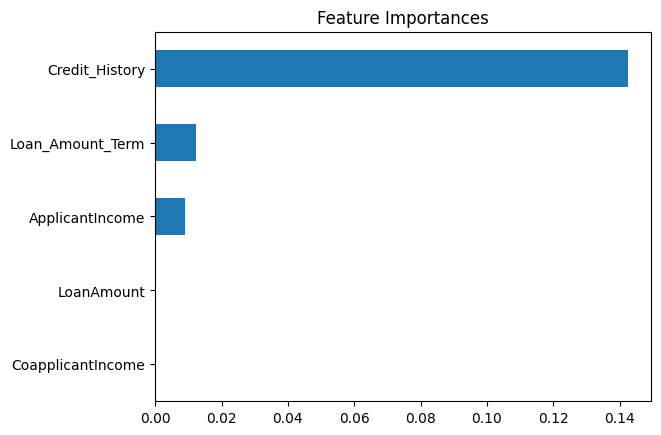

In [ ]:
#MUTUAL INFORMATION

X_pre_mutual = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                                  'Loan_Amount_Term', 'Credit_History']]
Y_pre_mutual = training_clean['Loan_Status']
discrete = [False, False, False, True, True]

importances = mutual_info_classif(X_pre_mutual, Y_pre_mutual, discrete_features=discrete, random_state=8)
feat_importances = pd.Series(importances, index=X_pre_mutual.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', title='Feature Importances')

**Using boxplots and histograms to find anomalous values in the continuous data [helps gauge which method of standardization to use]**

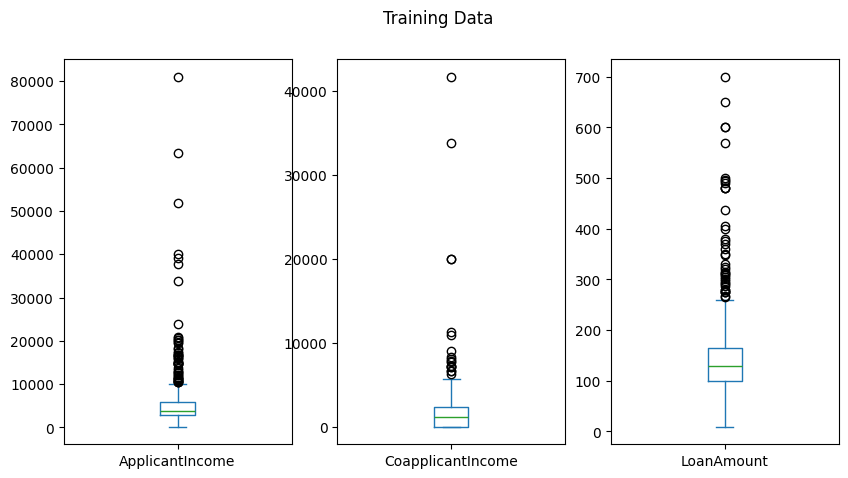

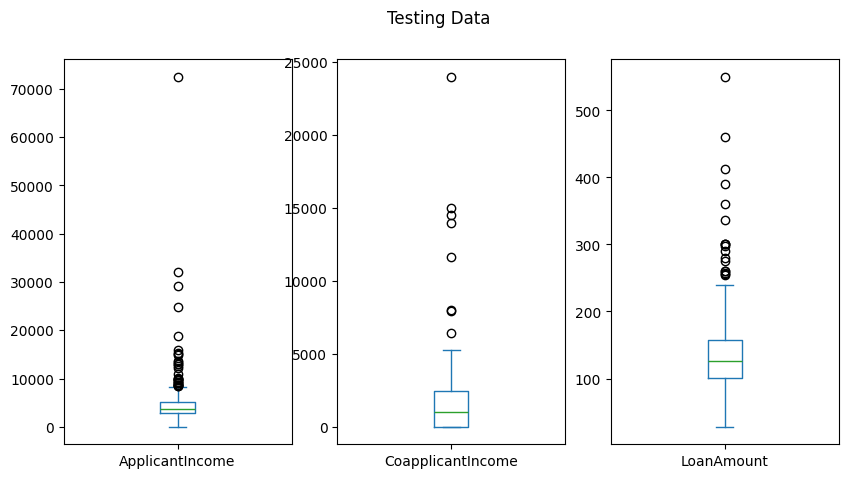

In [ ]:
anomaly_train_cols = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
anomaly_test_cols = test_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]

anomaly_train_cols.plot(kind='box', title='Training Data', figsize=(10,5), subplots=True, sharey=False)
plt.show()
anomaly_test_cols.plot(kind='box', title='Testing Data', figsize=(10,5), subplots=True, sharey=False)
plt.show()

In [ ]:
print(training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].skew())

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.726601
dtype: float64
ApplicantIncome      8.441375
CoapplicantIncome    4.257357
LoanAmount           2.238688
dtype: float64


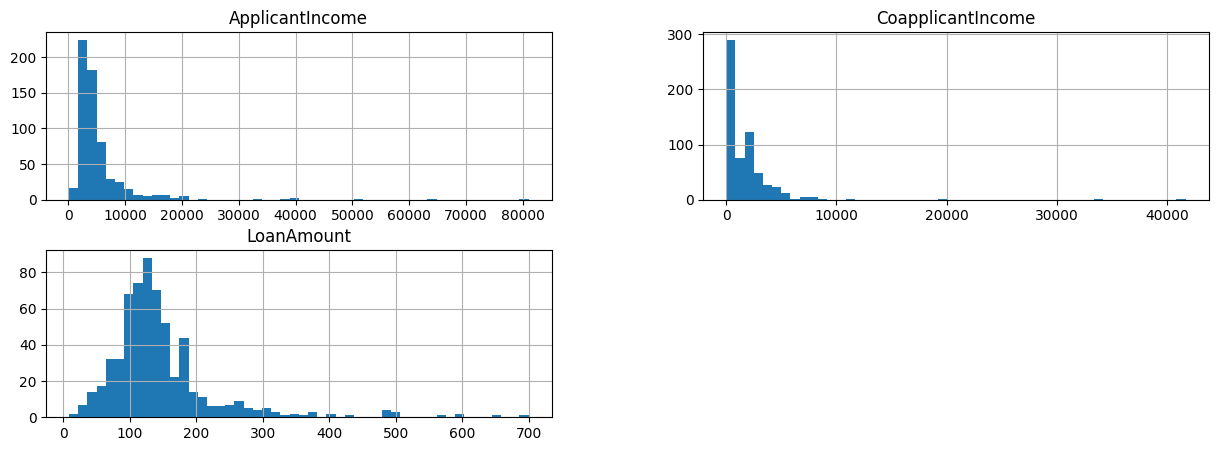

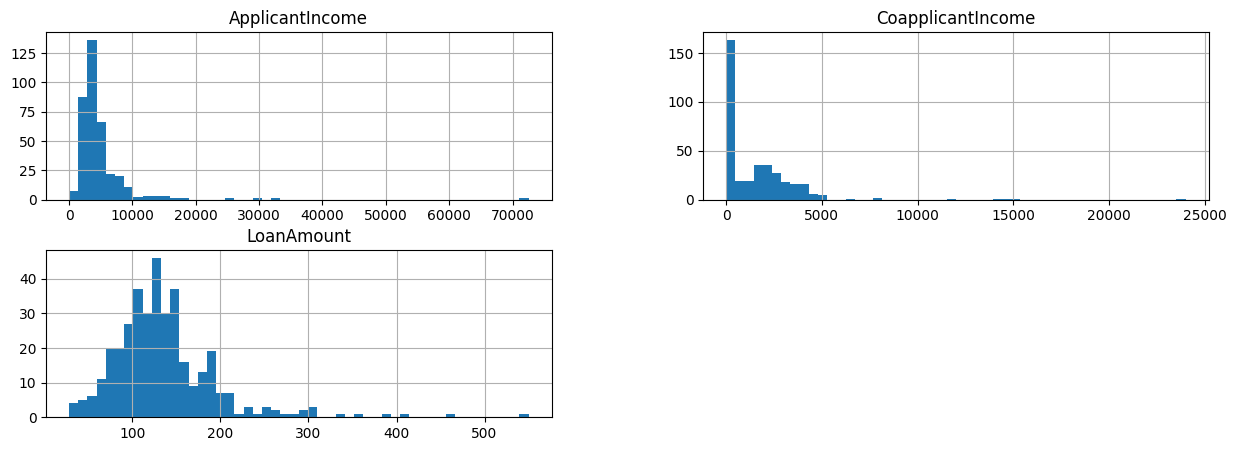

In [ ]:
training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].hist(bins=50, figsize=(15,5))
plt.show()

test_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].hist(bins=50, figsize=(15,5))
plt.show()

Data is indeed very skewed and has many outliers, so we'll want to standardize in a manner that's robust against outliers

# Standardizing data

In [ ]:
scaler = RobustScaler()
standardized_cols = ['ApplicantIncome', 'CoapplicantIncome',
                                             'LoanAmount', 'Loan_Amount_Term']

training_clean[standardized_cols] = training_clean[standardized_cols].apply(np.log1p)
test_clean[standardized_cols] = test_clean[standardized_cols].apply(np.log1p)


training_clean[standardized_cols] = scaler.fit_transform(training_clean[standardized_cols])
test_clean[standardized_cols] = scaler.transform(test_clean[standardized_cols])

display(training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']].head())
display(test_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']].head())

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,0.611367,-0.914886,0.255021,0.0
1,0.262931,0.030760,-0.015667,0.0
2,-0.342338,-0.914886,-1.344797,0.0
3,-0.556094,0.088485,-0.145557,0.0
4,0.647778,-0.914886,0.179131,0.0


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,0.579508,-0.914886,-0.320565,0.0
1,-0.306605,0.030073,-0.047368,0.0
2,0.387329,0.053615,0.963291,0.0
3,-0.697200,0.098392,-0.512106,0.0
4,-0.216630,-0.914886,-1.010536,0.0


In [ ]:
print(training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].skew())

ApplicantIncome      0.482128
CoapplicantIncome   -0.173073
LoanAmount          -0.179713
dtype: float64


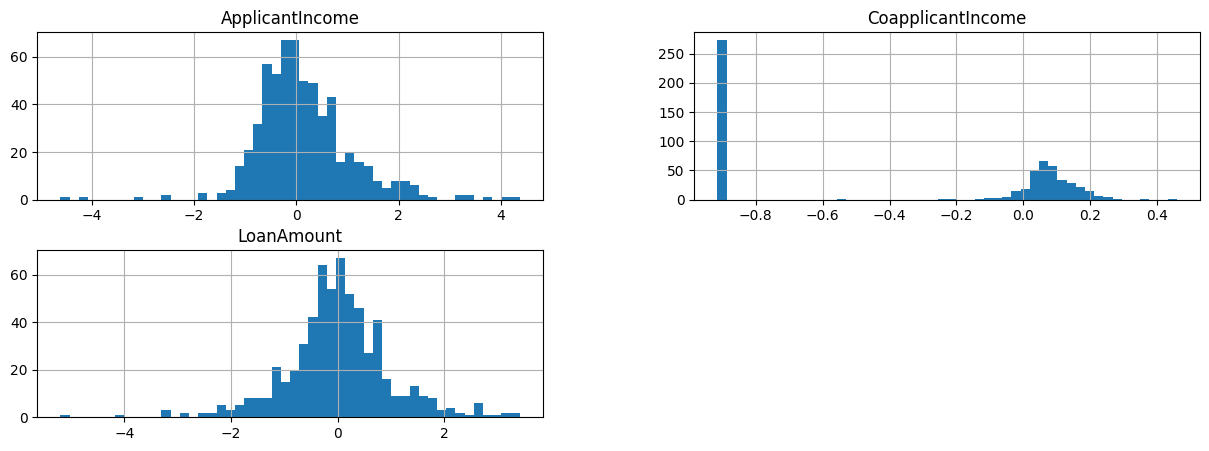

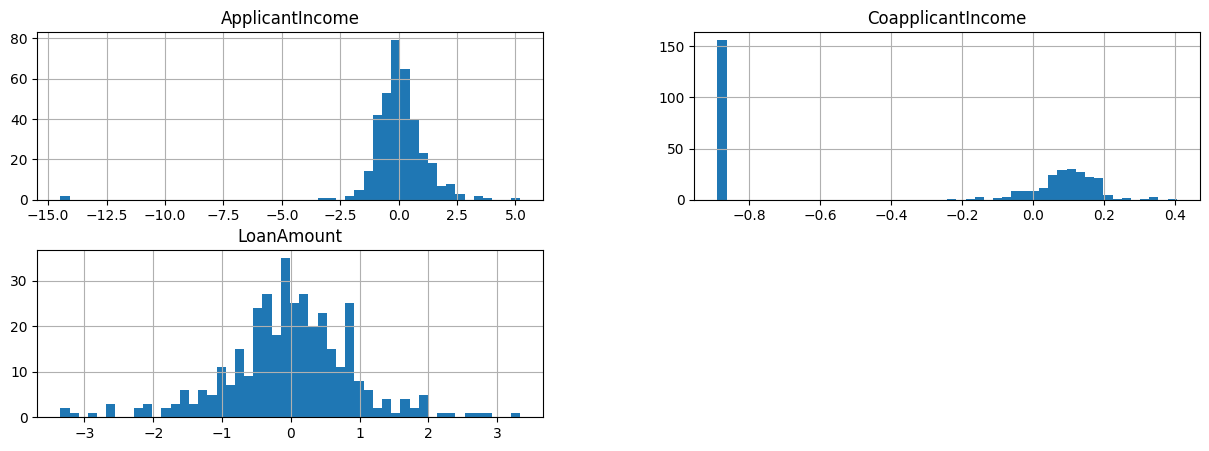

In [ ]:
training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].hist(bins=50, figsize=(15,5))
plt.show()

test_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].hist(bins=50, figsize=(15,5))
plt.show()

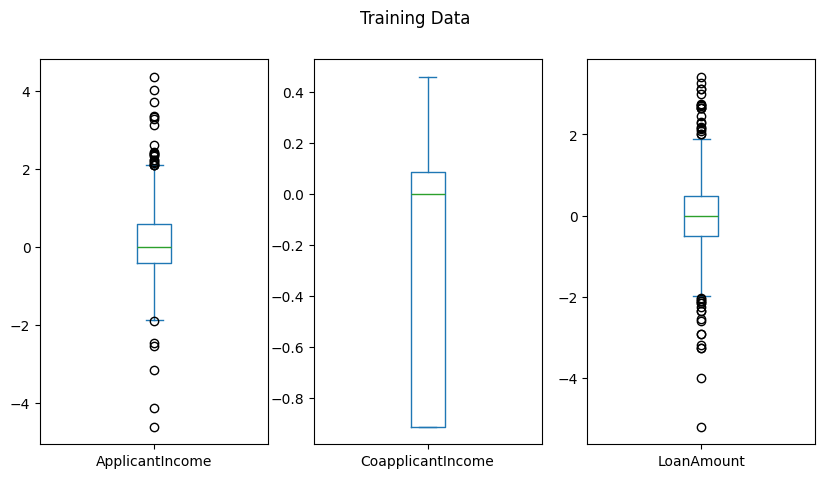

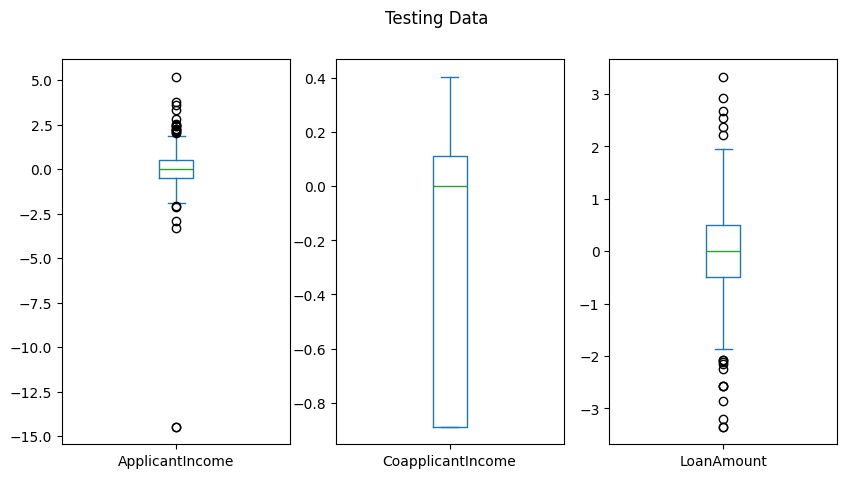

In [ ]:
anomaly_train_cols = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]
anomaly_test_cols = test_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]

anomaly_train_cols.plot(kind='box', title='Training Data', figsize=(10,5), subplots=True, sharey=False)
plt.show()
anomaly_test_cols.plot(kind='box', title='Testing Data', figsize=(10,5), subplots=True, sharey=False)
plt.show()

# Visualizing standardized data

In [ ]:
print(training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].skew())

ApplicantIncome      0.482128
CoapplicantIncome   -0.173073
LoanAmount          -0.179713
dtype: float64


In [ ]:
display(training_clean.describe(include='all'))

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
count,614,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.0,614.000000,614.000000,614.000000,614.000000
unique,614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
top,LP002990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,525.0,NaN,NaN,NaN,NaN
mean,NaN,0.817590,0.653094,0.744300,0.781759,0.133550,0.136030,-0.360599,0.006771,-0.082331,NaN,0.687296,0.291531,0.379479,0.328990
std,NaN,0.386497,0.476373,1.009623,0.413389,0.340446,0.921613,0.500765,0.996922,0.309785,NaN,0.463973,0.454838,0.485653,0.470229
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,-4.613562,-0.914886,-5.203860,-3.323929,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,-0.401885,-0.914886,-0.507109,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
50%,NaN,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000
75%,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,0.598115,0.085114,0.492891,0.000000,NaN,1.000000,1.000000,1.000000,1.000000


In [ ]:
display(test_clean.describe(include='all'))

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
count,367,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.0,367.000000,367.000000,367.000000
unique,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
top,LP002989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,308.0,NaN,NaN,NaN
mean,NaN,0.809264,0.634877,0.806540,0.771117,0.100817,0.003816,-0.345488,-0.062146,-0.088730,NaN,0.302452,0.316076,0.381471
std,NaN,0.393417,0.482122,1.065177,0.420687,0.301498,1.172004,0.495084,0.836553,0.375317,NaN,0.459947,0.465578,0.486411
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,-11.782149,-0.914886,-3.043737,-3.942968,NaN,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,-0.408602,-0.914886,-0.492118,0.000000,NaN,0.000000,0.000000,0.000000
50%,NaN,1.000000,1.000000,0.000000,1.000000,0.000000,-0.009963,-0.019083,-0.047368,0.000000,NaN,0.000000,0.000000,0.000000
75%,NaN,1.000000,1.000000,2.000000,1.000000,0.000000,0.404368,0.092394,0.402146,0.000000,NaN,1.000000,1.000000,1.000000


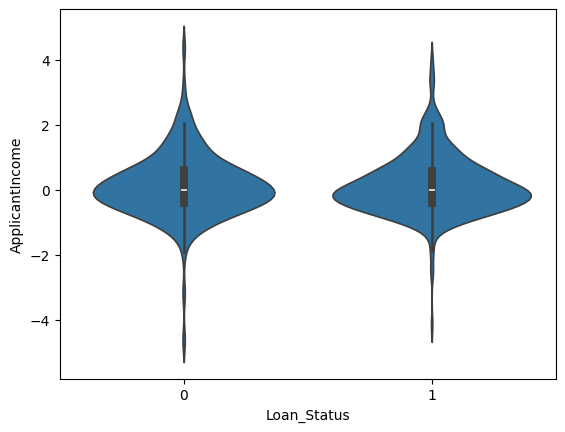

In [ ]:
sns.violinplot(x='Loan_Status', y='ApplicantIncome', data=training_clean)
plt.show()

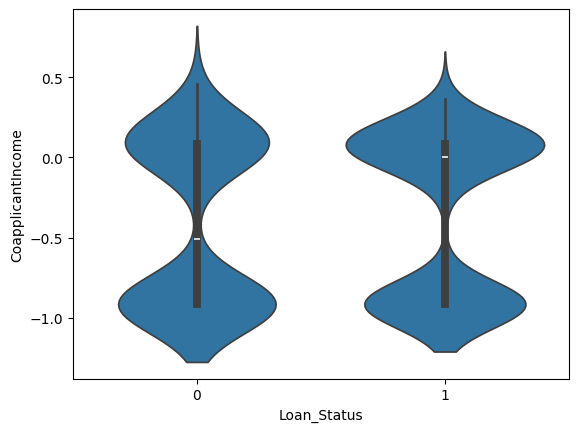

In [ ]:
sns.violinplot(x='Loan_Status', y='CoapplicantIncome', data=training_clean)
plt.show()

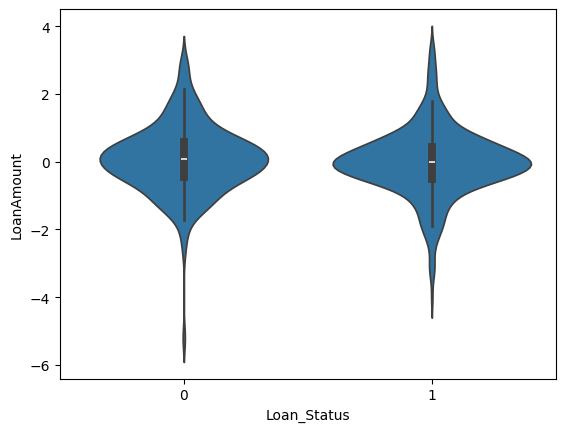

In [ ]:
sns.violinplot(x='Loan_Status', y='LoanAmount', data=training_clean)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


<Axes: title={'center': 'Feature Importances'}>

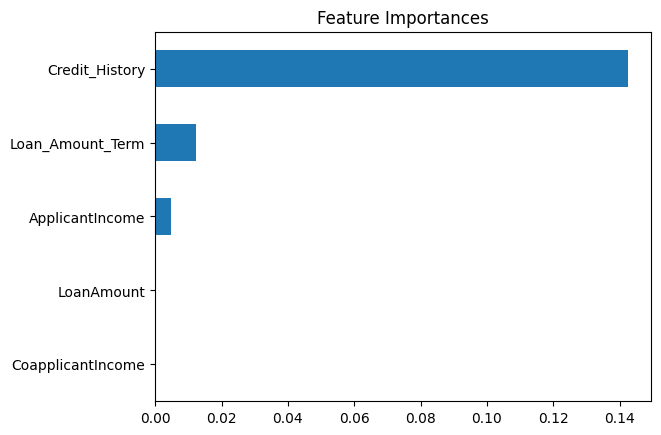

In [ ]:
X_post_mutual = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                                  'Loan_Amount_Term', 'Credit_History']]
Y_post_mutual = training_clean['Loan_Status']
discrete = [False, False, False, True, True]

importances = mutual_info_classif(X_post_mutual, Y_post_mutual, discrete_features=discrete, random_state=8)
feat_importances = pd.Series(importances, index=X_post_mutual.columns).sort_values(ascending=True)
feat_importances.plot(kind='barh', title='Feature Importances')

In [ ]:
pearson_r = training_clean[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                            'Loan_Amount_Term', 'Credit_History', 'Loan_Status']].corr()
pearson_r.loc[['Loan_Status']].round(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
Loan_Status,0.01,0.06,-0.04,-0.01,0.54,1.0


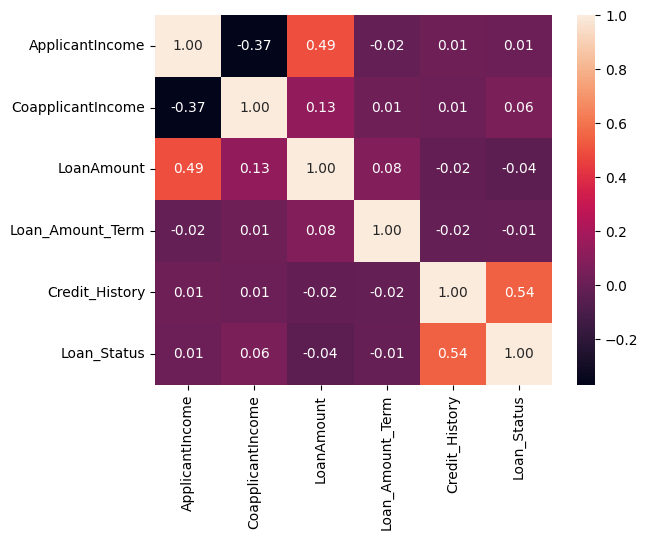

In [ ]:
sns.heatmap(pearson_r, annot=True, fmt=".2f")
plt.show()

# Cleaned + standardized training and test datasets export

In [ ]:
training_clean_filepath = "Loan approval TRAINING SET - CLEANED.csv"
test_clean_filepath = "Loan approval TEST SET - CLEANED.csv"

training_clean.to_csv(training_clean_filepath, index=False)
test_clean.to_csv(test_clean_filepath, index=False)